In [193]:
#Import library
import csv
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import heapq
from PIL import Image
from heapq import heappop, heappush
import math

<span style="color:red; font-size:24px; font-weight:bold;">ACTIVITY-1: For CSV file (env csv and visibility csv to get shortest part)</span>

In [194]:
# Function to read and process the environment CSV file
def process_csv(file_name):
    start_name = None
    target_name = None
    start_coordinates = None
    target_coordinates = None
    obstacles = {}

    try:
        # Open and read the environment CSV file
        with open(file_name, mode='r') as file:
            reader = csv.reader(file)
            rows = list(reader)[1:]  # Skip the header row

            if rows:
                # Extract start point
                start_name = rows[0][0]
                start_coordinates = (float(rows[0][1]), float(rows[0][2]))

                # Extract target point
                target_name = rows[-1][0]
                target_coordinates = (float(rows[-1][1]), float(rows[-1][2]))

                # Process obstacles
                for row in rows[1:-1]:  # Exclude the first and last rows
                    obstacle_name = row[0]
                    coordinates = (float(row[1]), float(row[2]))
                    if obstacle_name not in obstacles:
                        obstacles[obstacle_name] = []
                    obstacles[obstacle_name].append(coordinates)

        return start_name, start_coordinates, target_name, target_coordinates, obstacles
    except Exception as e:
        print(f"Error processing CSV file {file_name}: {e}")
        return None, None, None, None, {}

In [195]:
# Function to process the visibility graph CSV file
def process_visibility(file_name):
    visibility = []

    try:
        with open(file_name, mode='r') as file:
            reader = csv.reader(file)
            for row in reader:
                if row and len(row) >= 2:  # Ensure at least two columns
                    try:
                        x = float(row[0])
                        y = float(row[1])
                        visibility.append((x, y))
                    except ValueError:
                        continue  # Skip invalid rows
        return visibility
    except Exception as e:
        print(f"Error processing visibility file {file_name}: {e}")
        return []

In [196]:
# Function to merge start, obstacles, and target into a points dictionary
def merge_points(start_coordinates, obstacles, target_coordinates):
    points = {}
    idx = 0

    # Add start point
    points[idx] = start_coordinates
    idx += 1

    # Add obstacle points
    for obstacle_coords in obstacles.values():
        for coord in obstacle_coords:
            points[idx] = coord
            idx += 1

    # Add target point
    points[idx] = target_coordinates

    return points

In [197]:
#Function to plot environment with visibility lines
def plot_visibility_lines(start_name, start_coordinates, target_name, target_coordinates, obstacles,file_name,points, visibility):
    plt.figure(figsize=(6, 6))

    # Plot visibility lines
    for start_idx, end_idx in visibility:
        start_idx, end_idx = int(start_idx), int(end_idx)  # Ensure indices are integers
        if start_idx in points and end_idx in points:
            start_x, start_y = points[start_idx]
            end_x, end_y = points[end_idx]
            plt.plot([start_x, end_x], [start_y, end_y], 'b--', linewidth=1)  # Blue dotted line

    # Plot points as scatter points
    for idx, (x, y) in points.items():
        plt.scatter(x, y, color='black', zorder=5)  # Plot the point
        plt.text(x, y, f'{idx}', fontsize=8, ha='right', zorder=10)  # Annotate the index


    # Plot Obstacles
    for obstacle, coords in obstacles.items():
        coords_array = np.array(coords)
        coords_array = np.vstack([coords_array, coords_array[0]])  # Close the polygon
        plt.fill(coords_array[:, 0], coords_array[:, 1], 'r', alpha=0.3, label=f"Obstacle: {obstacle}")

        for coord in coords:
            plt.text(coord[0] + 0.1, coord[1], f"({coord[0]}, {coord[1]})", fontsize=8)

    # Annotate all points
    for idx, coord in points.items():
        plt.text(coord[0], coord[1], f"{idx}", fontsize=8, ha='right')

    # Plot Start and Target points
    plt.scatter(*start_coordinates, color='green', label=f"Start: {start_name}")
    plt.text(start_coordinates[0] + 0.1, start_coordinates[1], f"({start_coordinates[0]}, {start_coordinates[1]})", fontsize=15)
    plt.scatter(*target_coordinates, color='red', label=f"Target: {target_name}")
    plt.text(target_coordinates[0] + 0.1, target_coordinates[1], f"({target_coordinates[0]}, {target_coordinates[1]})", fontsize=15)

    plt.title(f"Visibility with Environment: {file_name}")
    plt.xlabel("X Coordinates")
    plt.ylabel("Y Coordinates")
    plt.grid(True)
    plt.xlabel("X Coordinates")
    plt.ylabel("Y Coordinates")
    plt.legend()
    plt.show()

In [198]:
# Heuristic: Euclidean distance
def heuristic(point1, point2):
    return np.linalg.norm(np.array(point1) - np.array(point2))

In [199]:
# A* Algorithm
def a_star(points, visibility, start_idx, target_idx):
    open_set = []
    heapq.heappush(open_set, (0, start_idx))  # (f, node)

    came_from = {}
    g_score = {node: float('inf') for node in points}
    g_score[start_idx] = 0

    f_score = {node: float('inf') for node in points}
    f_score[start_idx] = heuristic(points[start_idx], points[target_idx])

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == target_idx:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start_idx)
            return path[::-1]  # Reverse the path

        for neighbor in [end for start, end in visibility if start == current] + \
                        [start for start, end in visibility if end == current]:
            tentative_g_score = g_score[current] + heuristic(points[current], points[neighbor])

            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = g_score[neighbor] + heuristic(points[neighbor], points[target_idx])
                if neighbor not in [i[1] for i in open_set]:
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

    return None  # Path not found

In [200]:
# Plot environment with shortest path
def plot_environment_with_path(start_name, start_coordinates, target_name, target_coordinates, obstacles, file_name, points, visibility, path):
    plt.figure(figsize=(6, 6))

    # Plot visibility lines
    for start_idx, end_idx in visibility:
        if start_idx in points and end_idx in points:
            start_x, start_y = points[start_idx]
            end_x, end_y = points[end_idx]
            plt.plot([start_x, end_x], [start_y, end_y], 'b--', linewidth=1)

    # Plot obstacles
    for obstacle, coords in obstacles.items():
        coords_array = np.array(coords)
        coords_array = np.vstack([coords_array, coords_array[0]])
        plt.fill(coords_array[:, 0], coords_array[:, 1], 'r', alpha=0.3)

    # Plot shortest path
    if path:
        path_coords = [points[idx] for idx in path]
        path_x, path_y = zip(*path_coords)
        plt.plot(path_x, path_y, 'g-', linewidth=2, label="Shortest Path")

    # Plot start and target
    plt.scatter(*start_coordinates, color='green', label="Start")
    plt.text(start_coordinates[0] + 0.1, start_coordinates[1], "Start", fontsize=12)
    plt.scatter(*target_coordinates, color='red', label="Target")
    plt.text(target_coordinates[0] + 0.1, target_coordinates[1], "Target", fontsize=12)

    plt.title(f"Environment with Shortest Path: {file_name}")
    plt.xlabel("X Coordinates")
    plt.ylabel("Y Coordinates")
    plt.legend()
    plt.grid(True)
    plt.show()

Start Coordinates: (14.0, 10.1)
Target Coordinates: (37.5, 23.8)
Obstacles: {'1': [(17.0, 16.5), (14.9, 16.9), (13.2, 18.4), (12.2, 21.5), (13.0, 25.0), (17.1, 25.4), (22.0, 24.4), (25.5, 25.0), (28.2, 24.3), (28.5, 21.4), (28.9, 18.5), (31.2, 16.8), (33.7, 16.3), (36.3, 15.9), (39.2, 16.5), (42.8, 17.6), (46.5, 16.8), (42.8, 15.2), (37.8, 12.9), (35.0, 12.0), (28.9, 12.3), (25.0, 12.8), (22.3, 15.0), (20.1, 17.7), (18.6, 20.6), (17.3, 22.5), (14.9, 23.2), (15.7, 21.5), (15.4, 19.6), (16.5, 18.0)]}
Points: {0: (14.0, 10.1), 1: (17.0, 16.5), 2: (14.9, 16.9), 3: (13.2, 18.4), 4: (12.2, 21.5), 5: (13.0, 25.0), 6: (17.1, 25.4), 7: (22.0, 24.4), 8: (25.5, 25.0), 9: (28.2, 24.3), 10: (28.5, 21.4), 11: (28.9, 18.5), 12: (31.2, 16.8), 13: (33.7, 16.3), 14: (36.3, 15.9), 15: (39.2, 16.5), 16: (42.8, 17.6), 17: (46.5, 16.8), 18: (42.8, 15.2), 19: (37.8, 12.9), 20: (35.0, 12.0), 21: (28.9, 12.3), 22: (25.0, 12.8), 23: (22.3, 15.0), 24: (20.1, 17.7), 25: (18.6, 20.6), 26: (17.3, 22.5), 27: (14.9, 

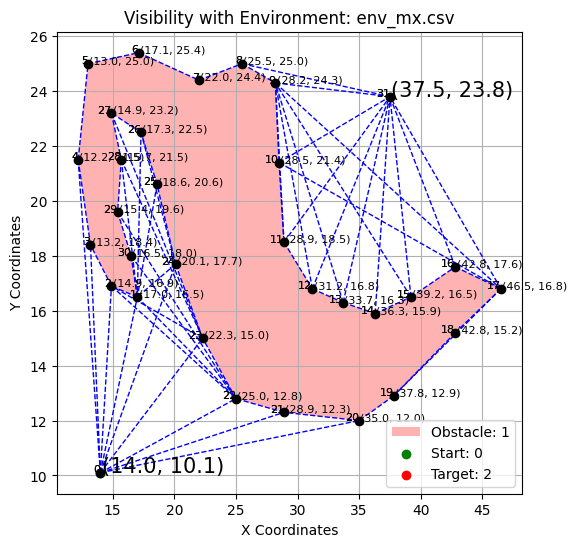

Shortest Path: [0, 4.0, 5.0, 6.0, 7.0, 8.0, 31.0]


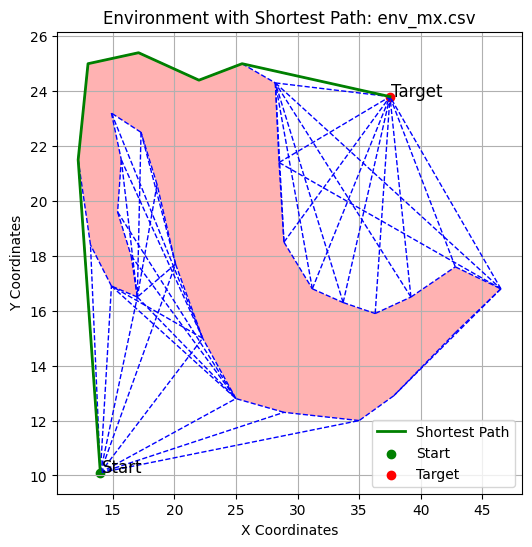

In [201]:
#main function to get output==> user input interface
def main():
    env_files = ["env_0.csv", "env_1.csv", "env_2.csv", "env_mx.csv"]
    visibility_files = ["visibility_graph_env_0.csv", "visibility_graph_env_1.csv", "visibility_graph_env_2.csv", "visibility_graph_env_mx.csv"]

    try:
        # User input
        user_input = int(input("Enter a number between 0 and 3 to select the environment and visibility: "))

        if 0 <= user_input < len(env_files):
            selected_env_file = env_files[user_input]
            selected_visibility_file = visibility_files[user_input]

            # Process environment and visibility files
            start_name, start_coordinates, target_name, target_coordinates, obstacles = process_csv(selected_env_file)
            visibility = process_visibility(selected_visibility_file)

            if start_coordinates and target_coordinates:
                points = merge_points(start_coordinates, obstacles, target_coordinates)

                start_idx = 0
                target_idx = max(points.keys())  # Assuming target is the last point
                
                print("Start Coordinates:", start_coordinates)
                print("Target Coordinates:", target_coordinates)
                print("Obstacles:", obstacles)
                print("Points:", points)
                print("Visibility:", visibility)

                # Plot visibility lines
                plot_visibility_lines(start_name, start_coordinates, target_name, target_coordinates, obstacles,selected_env_file,points, visibility)

                # Run A* to find the shortest path
                path = a_star(points, visibility, start_idx, target_idx)
                print("Shortest Path:", path)

                # Plot environment with shortest path
                plot_environment_with_path(start_name, start_coordinates, target_name, target_coordinates, obstacles, selected_env_file, points, visibility, path)

            else:
                print("Error: Failed to process environment file.")
        else:
            print("Invalid input. Please enter a number between 0 and 3.")
    except ValueError:
        print("Invalid input. Please enter a valid integer.")

if __name__ == "__main__":
    main()

<span style="color:red; font-size:24px; font-weight:bold;">ACTIVITY-2: For grid maps</span>

#Loading Grid Map through User Input 

#Start and Goal Position in Grid Map

In [202]:
# Define start and goal positions for each map
start_goal_positions = {
    "map0.png": ((10, 10), (90, 70)),
    "map1.png": ((60, 60), (90, 60)),
    "map2.png": ((8, 31), (139, 38)),
    "map3.png": ((50, 90), (375, 375)),
}

In [203]:
#process gridmap
def load_and_process_map(map_filename):
    """
    Load and preprocess the grid map.
    """
    image = Image.open(map_filename).convert('L')
    grid_map = np.array(image.getdata()).reshape(image.size[1], image.size[0]) / 255
    grid_map[grid_map > 0.5] = 1
    grid_map[grid_map <= 0.5] = 0
    grid_map = (grid_map * -1) + 1  # Invert: 0 -> free, 1 -> occupied
    return grid_map

In [204]:
#Neignbour node
def get_neighbors(node, grid_map, connectivity=4):
    """
    Get valid neighbors for 4-point or 8-point connectivity.
    """
    x, y = node
    if connectivity == 4:
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # Cardinal directions
    elif connectivity == 8:
        directions = [
            (0, 1), (1, 0), (0, -1), (-1, 0),  # Cardinal directions
            (1, 1), (1, -1), (-1, -1), (-1, 1)  # Diagonal directions
        ]
    else:
        raise ValueError("Connectivity must be 4 or 8.")

    neighbors = []
    for dx, dy in directions:
        nx, ny = x + dx, y + dy
        if 0 <= nx < grid_map.shape[0] and 0 <= ny < grid_map.shape[1]:
            if grid_map[nx, ny] == 0:  # Free space
                neighbors.append((nx, ny))
    return neighbors

In [205]:
#path reconstruction
def reconstruct_path(came_from, current):
    """
    Reconstruct the path from start to goal.
    """
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path

In [206]:
#A* algorithm function
def a_star(grid_map, start, goal, connectivity=4):
    """
    A* pathfinding algorithm.
    """
    open_set = []
    heappush(open_set, (0, start))
    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}

    while open_set:
        _, current = heappop(open_set)

        if current == goal:
            path = reconstruct_path(came_from, current)
            cost = sum(heuristic(path[i], path[i + 1]) for i in range(len(path) - 1))
            return path, cost

        for neighbor in get_neighbors(current, grid_map, connectivity):
            tentative_g_score = g_score[current] + heuristic(current, neighbor)
            if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = tentative_g_score + heuristic(neighbor, goal)
                heappush(open_set, (f_score[neighbor], neighbor))

    return None, float('inf')  # No path found

In [207]:
#grid map plot function
def plot_grid_map_with_positions(grid_map, start, goal, path, map_filename):
    """
    Plot the grid map with start, goal, and path positions marked.
    """
    plt.figure(figsize=(6, 6))
    plt.matshow(grid_map, fignum=1)
    plt.scatter(start[1], start[0], color='green', label='Start')  # (y, x) for scatter
    plt.scatter(goal[1], goal[0], color='red', label='Goal')

    # Plot the path (if available)
    if path:
        path_x, path_y = zip(*path)
        plt.plot(path_y, path_x, color='red', label='Path')

    plt.legend()
    plt.title(f"Grid Map: {map_filename} with Start, Goal, and Path")
    plt.colorbar()
    plt.show()

4-Point Connectivity:
Path: [(50, 90), (51, 90), (52, 90), (53, 90), (54, 90), (55, 90), (56, 90), (57, 90), (58, 90), (59, 90), (60, 90), (61, 90), (62, 90), (63, 90), (64, 90), (65, 90), (66, 90), (67, 90), (68, 90), (69, 90), (70, 90), (71, 90), (72, 90), (73, 90), (74, 90), (75, 90), (76, 90), (77, 90), (78, 90), (79, 90), (80, 90), (81, 90), (82, 90), (83, 90), (84, 90), (85, 90), (86, 90), (87, 90), (87, 91), (87, 92), (87, 93), (87, 94), (87, 95), (87, 96), (87, 97), (87, 98), (87, 99), (87, 100), (87, 101), (87, 102), (87, 103), (87, 104), (87, 105), (87, 106), (87, 107), (87, 108), (87, 109), (87, 110), (87, 111), (87, 112), (88, 112), (88, 113), (88, 114), (89, 114), (89, 115), (90, 115), (90, 116), (91, 116), (91, 117), (92, 117), (92, 118), (93, 118), (93, 119), (93, 120), (94, 120), (94, 121), (95, 121), (95, 122), (96, 122), (97, 122), (97, 123), (98, 123), (98, 124), (99, 124), (99, 125), (100, 125), (100, 126), (101, 126), (102, 126), (102, 127), (103, 127), (104, 127),

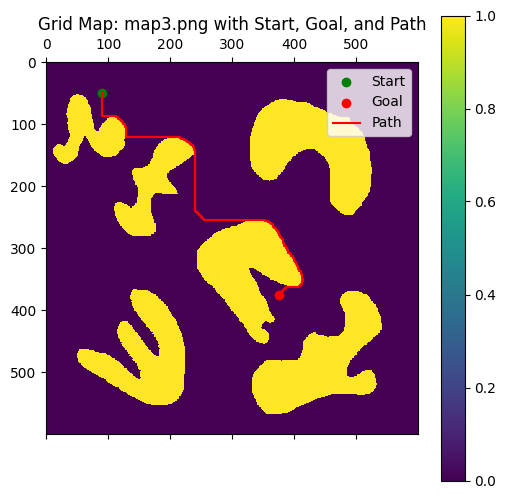

8-Point Connectivity:
Path: [(50, 90), (51, 91), (51, 92), (52, 93), (53, 94), (53, 95), (53, 96), (53, 97), (53, 98), (53, 99), (53, 100), (53, 101), (53, 102), (53, 103), (53, 104), (53, 105), (53, 106), (53, 107), (53, 108), (53, 109), (53, 110), (53, 111), (53, 112), (53, 113), (53, 114), (53, 115), (53, 116), (53, 117), (53, 118), (53, 119), (53, 120), (54, 121), (55, 122), (56, 123), (57, 124), (58, 125), (59, 126), (60, 127), (61, 128), (62, 129), (63, 130), (64, 131), (65, 132), (66, 133), (67, 134), (68, 135), (69, 136), (70, 137), (71, 138), (72, 139), (73, 140), (74, 141), (75, 142), (76, 143), (76, 144), (77, 145), (78, 146), (79, 147), (80, 148), (81, 149), (82, 150), (83, 151), (84, 152), (85, 153), (86, 154), (87, 155), (88, 156), (89, 157), (90, 158), (91, 159), (92, 160), (93, 161), (94, 162), (95, 163), (96, 164), (97, 165), (98, 166), (99, 167), (100, 168), (101, 169), (102, 170), (103, 171), (104, 172), (105, 173), (106, 174), (107, 175), (108, 176), (109, 177), (11

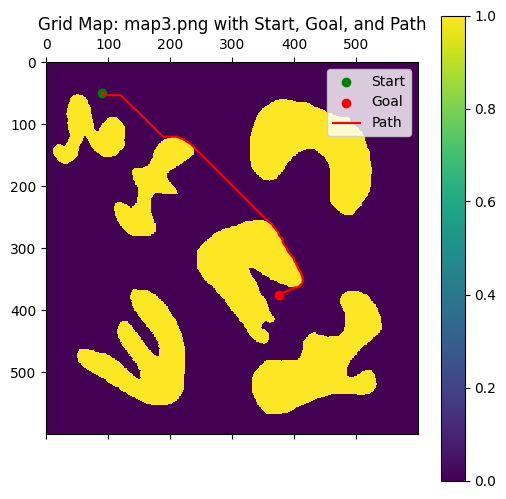

In [208]:
#main function to get output==> user input interface
def main():
    """
    Main function to handle user input and pathfinding.
    """
    map_choice = input("Enter a number (0, 1, 2, 3) to select the map: ")
    
    if map_choice not in ['0', '1', '2', '3']:
        print("Invalid choice! Please enter 0, 1, 2, or 3.")
        return

    map_filename = f"map{map_choice}.png"

    try:
        # Load and process the selected map
        grid_map = load_and_process_map(map_filename)
        
        # Get start and goal positions
        start, goal = start_goal_positions[map_filename]
        
        # Run A* for 4-point connectivity
        path_4, cost_4 = a_star(grid_map, start, goal, connectivity=4)
        print("4-Point Connectivity:")
        print("Path:", path_4)
        print("Cost:", cost_4)
        plot_grid_map_with_positions(grid_map, start, goal, path_4, map_filename)

        # Run A* for 8-point connectivity
        path_8, cost_8 = a_star(grid_map, start, goal, connectivity=8)
        print("8-Point Connectivity:")
        print("Path:", path_8)
        print("Cost:", cost_8)
        plot_grid_map_with_positions(grid_map, start, goal, path_8, map_filename)

    except FileNotFoundError:
        print(f"Error: The file '{map_filename}' was not found. Please ensure the file exists in the directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    main()
